In [ ]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.7 MB/s eta 0:00:00


In [ ]:
# 1. Import the libraries
import pandas as pd
import numpy as np
from arch import arch_model
import matplotlib.pyplot as plt

In [ ]:
# 2. Import the dataset, extract the Log Returns (and multiply by 100 for better convergence)
# GARCH likes percentages; it makes the math "comfortable"
df = pd.read_csv("/content/vvix_unscaled.csv")
returns = 100 * df['VVIX_Close_Log_Return'].dropna()
print(returns)

0      -1.452674
1      -3.012911
2      -2.506610
3       2.549280
4       3.986591
          ...   
4683   -7.167302
4684    3.513558
4685   -0.882525
4686   -2.823939
4687    0.939573
Name: VVIX_Close_Log_Return, Length: 4688, dtype: float64


In [ ]:
# 3. Build the model
model = arch_model(
    returns,
    vol = "GARCH",
    p = 1,
    q = 1,
    mean = 'Constant',
    dist = 'normal'
)

results = model.fit()
print(results.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 27467.90136966245
Iteration:      2,   Func. Count:     14,   Neg. LLF: 27078.875069667847
Iteration:      3,   Func. Count:     21,   Neg. LLF: 2573223932.9425426
Iteration:      4,   Func. Count:     27,   Neg. LLF: 14214.627559967343
Iteration:      5,   Func. Count:     33,   Neg. LLF: 14156.432046282669
Iteration:      6,   Func. Count:     39,   Neg. LLF: 14111.152290643022
Iteration:      7,   Func. Count:     45,   Neg. LLF: 14109.759874971105
Iteration:      8,   Func. Count:     50,   Neg. LLF: 14109.759447994787
Iteration:      9,   Func. Count:     55,   Neg. LLF: 14109.75944486144
Iteration:     10,   Func. Count:     59,   Neg. LLF: 14109.759444861675
Optimization terminated successfully    (Exit mode 0)
            Current function value: 14109.75944486144
            Iterations: 10
            Function evaluations: 59
            Gradient evaluations: 10
                       Constant Mean - GARCH Model Results     

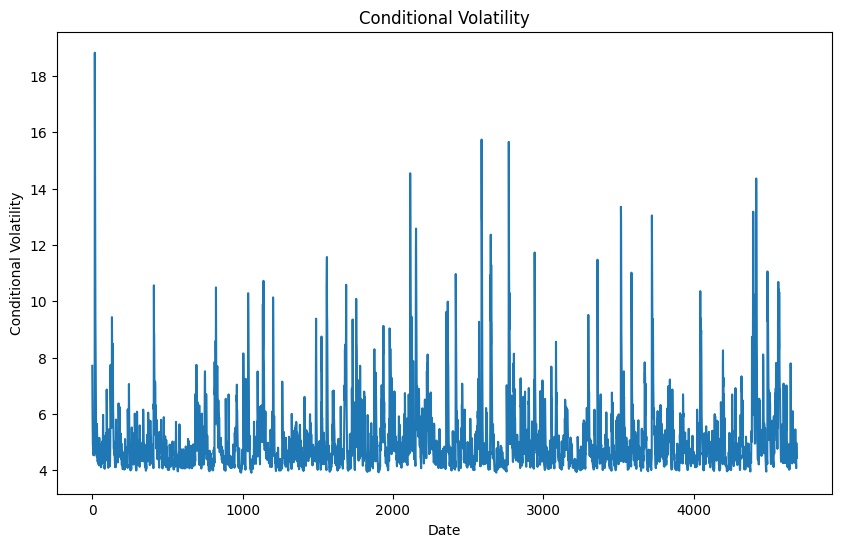

In [ ]:
# 4. Plot the conditional volatility
plt.figure(figsize=(10, 6))
plt.plot(results.conditional_volatility)
plt.title('Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.show()

In [ ]:
# 5. Evaluate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Extract the predicted variance
pred_var = results.conditional_volatility ** 2

# Prepare actual variance proxy
actual_var = returns ** 2

# Calculate the MSE, MAE and R2
mse = mean_squared_error(actual_var, pred_var)
mae = mean_absolute_error(actual_var, pred_var)
r2 = r2_score(actual_var, pred_var)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2: {r2}")

# Calculate directional accuracy
directional_accuracy = np.mean(np.sign(returns) == np.sign(pred_var))
print(f"Directional Accuracy: {directional_accuracy}")

MSE: 5202.352873515041
MAE: 28.949130585166007
R2: 0.034610978982534846
Directional Accuracy: 0.4515784982935154


In [ ]:
# SHAP Analysis